[From Tasks to Assets: Building Modern Data Pipelines with Airflow 3.0’s Asset-Based Orchestration](https://medium.com/@daniel.groth/from-tasks-to-assets-building-modern-data-pipelines-with-airflow-3-0s-asset-based-orchestration-b341fa757e30)

learn from: https://academy.astronomer.io/path/airflow-101

Data Orchestration Fundamentals

- Data Orchestration is the coordination and automation of data flow across various tools and systems to deliver quality data products and analytics
- The path to modern data orchestration solutions like Airflow had various evolutions starting with basic time-based scheduling tools (e.g., Cron, WTS), followed by proprietary software (e.g., AutoSys, Informatica), and finally older open-source solutions (e.g., Oozie, Luigi).

Airflow for Data Orchestration

- Airflow is an open-source tool for programmatically authoring, scheduling, and monitoring data pipelines.
- Airflow is defined by key characteristics such as pipelines-as-code with Python, built-in observability, a large open-source community, and much more!
- Airflow is used across a variety of industries, data practitioners, and use-cases.
- Airflow has key considerations to account for when using it for streaming, data processing, and when it is scaled. 

Demystifying Airflow

- Airflow can be used by single developers, single teams, and multi-teams. In each case, the way it is run is different.
- Airflow can be run using a variety of architecture types (e.g., on-premise) and systems (e.g., cloud services)
- Airflow key terms to remember:
  - DAG: A directed acyclical graph that represents a single data pipeline
  - Task: An individual unit of work in a DAG
  - Operator: The specific work that a Task performs 
- There are three main types of operators:
  - Action: Perform a specific action such as running code or a bash command
  - Transfer: Perform transfer operations that move data between two systems
  - Sensor: Wait for a specific condition to be met (e.g., waiting for a file to be present) before running the next task

## airflow components:  
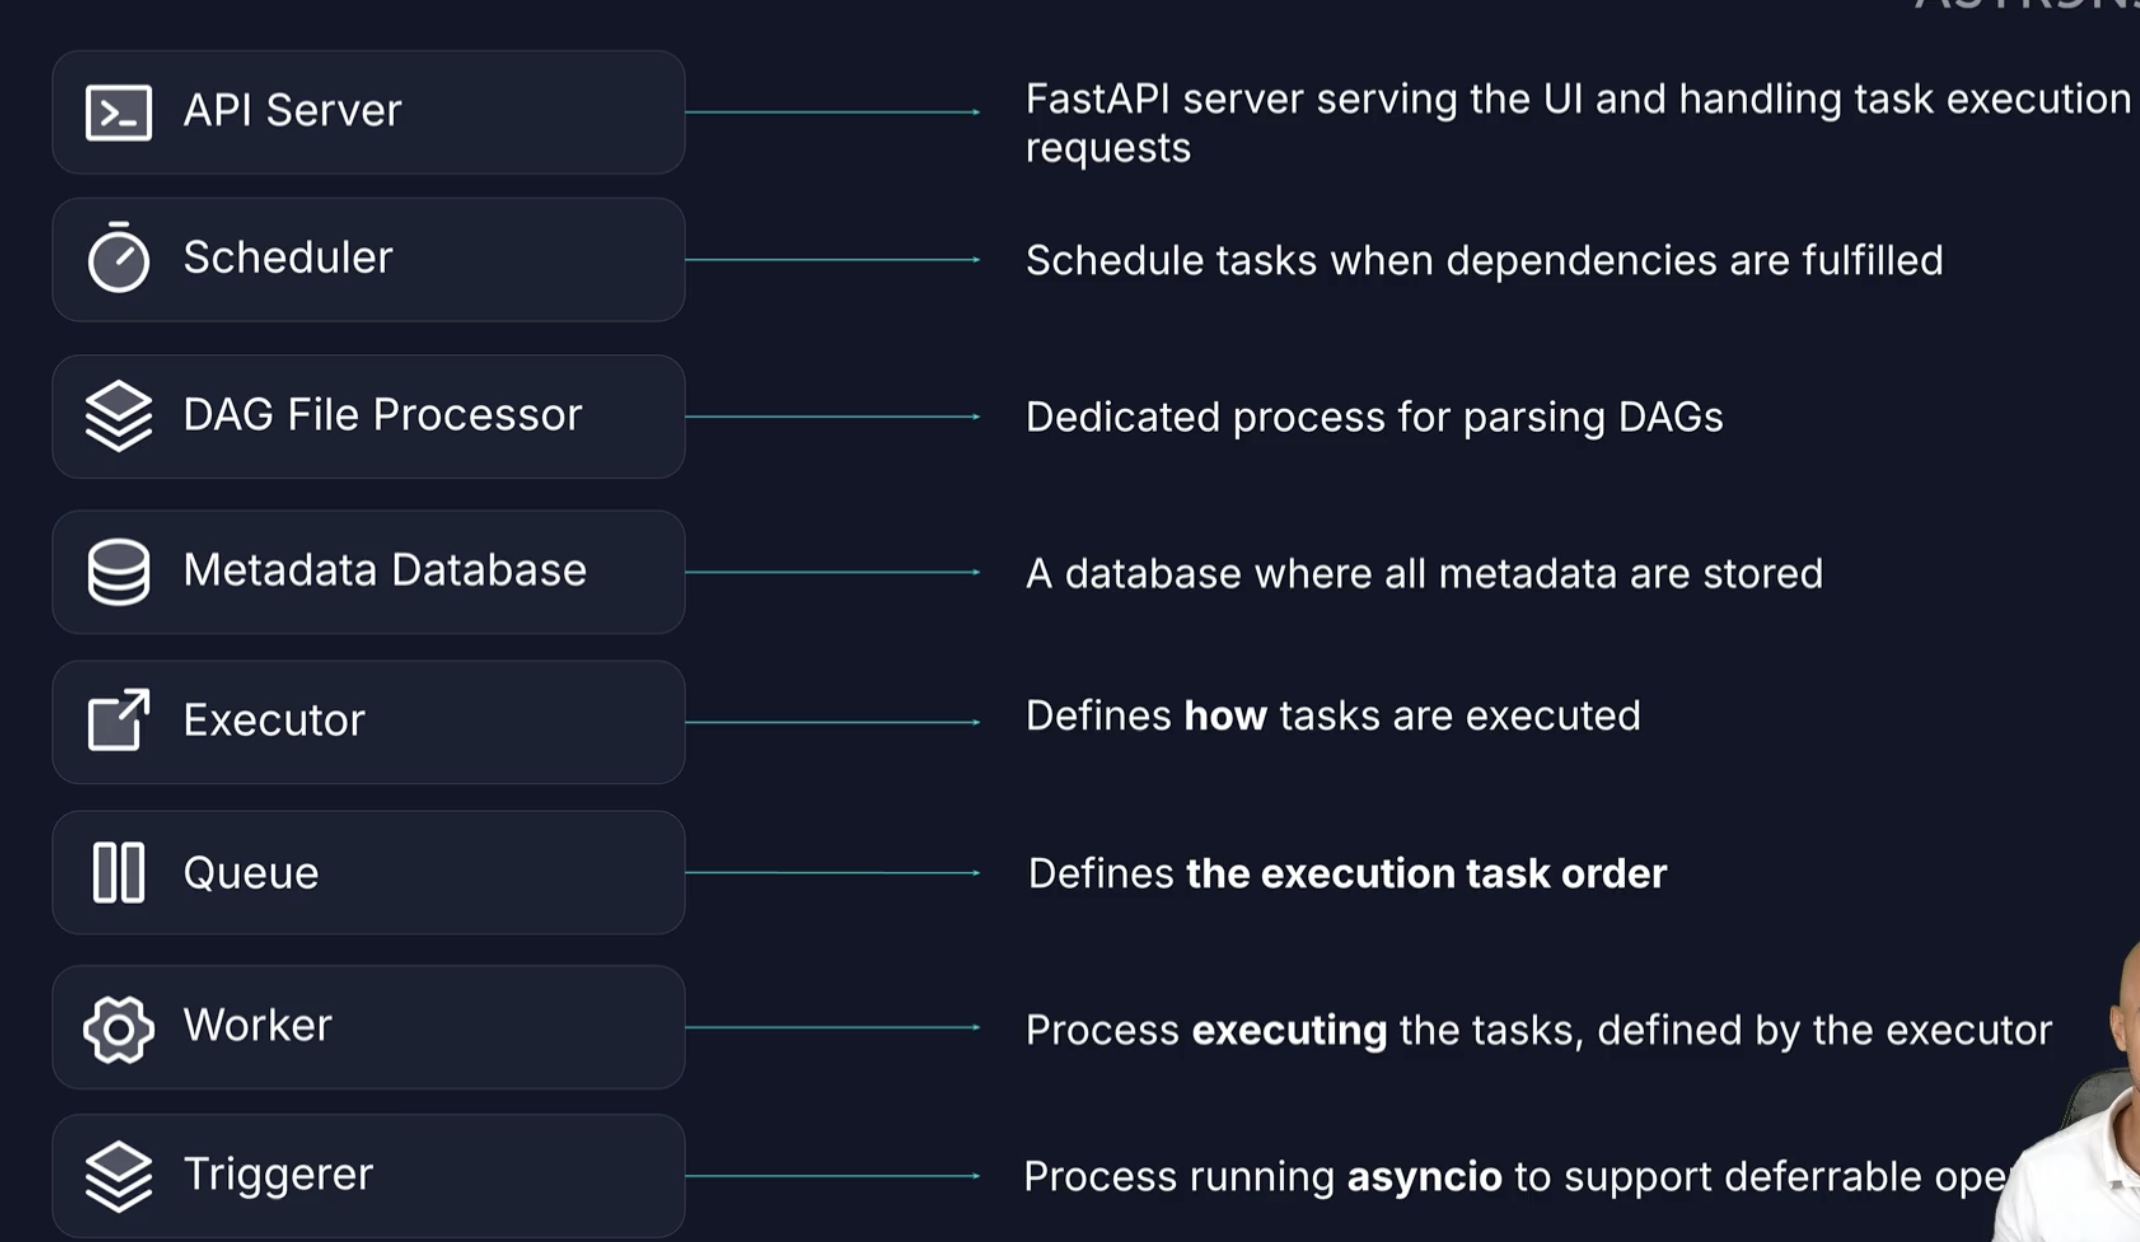
Airflow has seven main components:
- The API server for serving the Airflow UI and providing endpoints for Workers to communicate with the Airflow DB.
- The metadata database is used to store all metadata (e.g., users, tasks) related to your Airflow instance.
- The scheduler for monitoring and scheduling your pipelines.
- The executor defines how and on which system tasks are executed.
- The DAG File Processor that retrieves and parses DAG files.
- The queue for holding tasks that are ready to be executed.
- The worker(s) for executing instructions defined in a task.

## How Does Airflow Run a DAG?
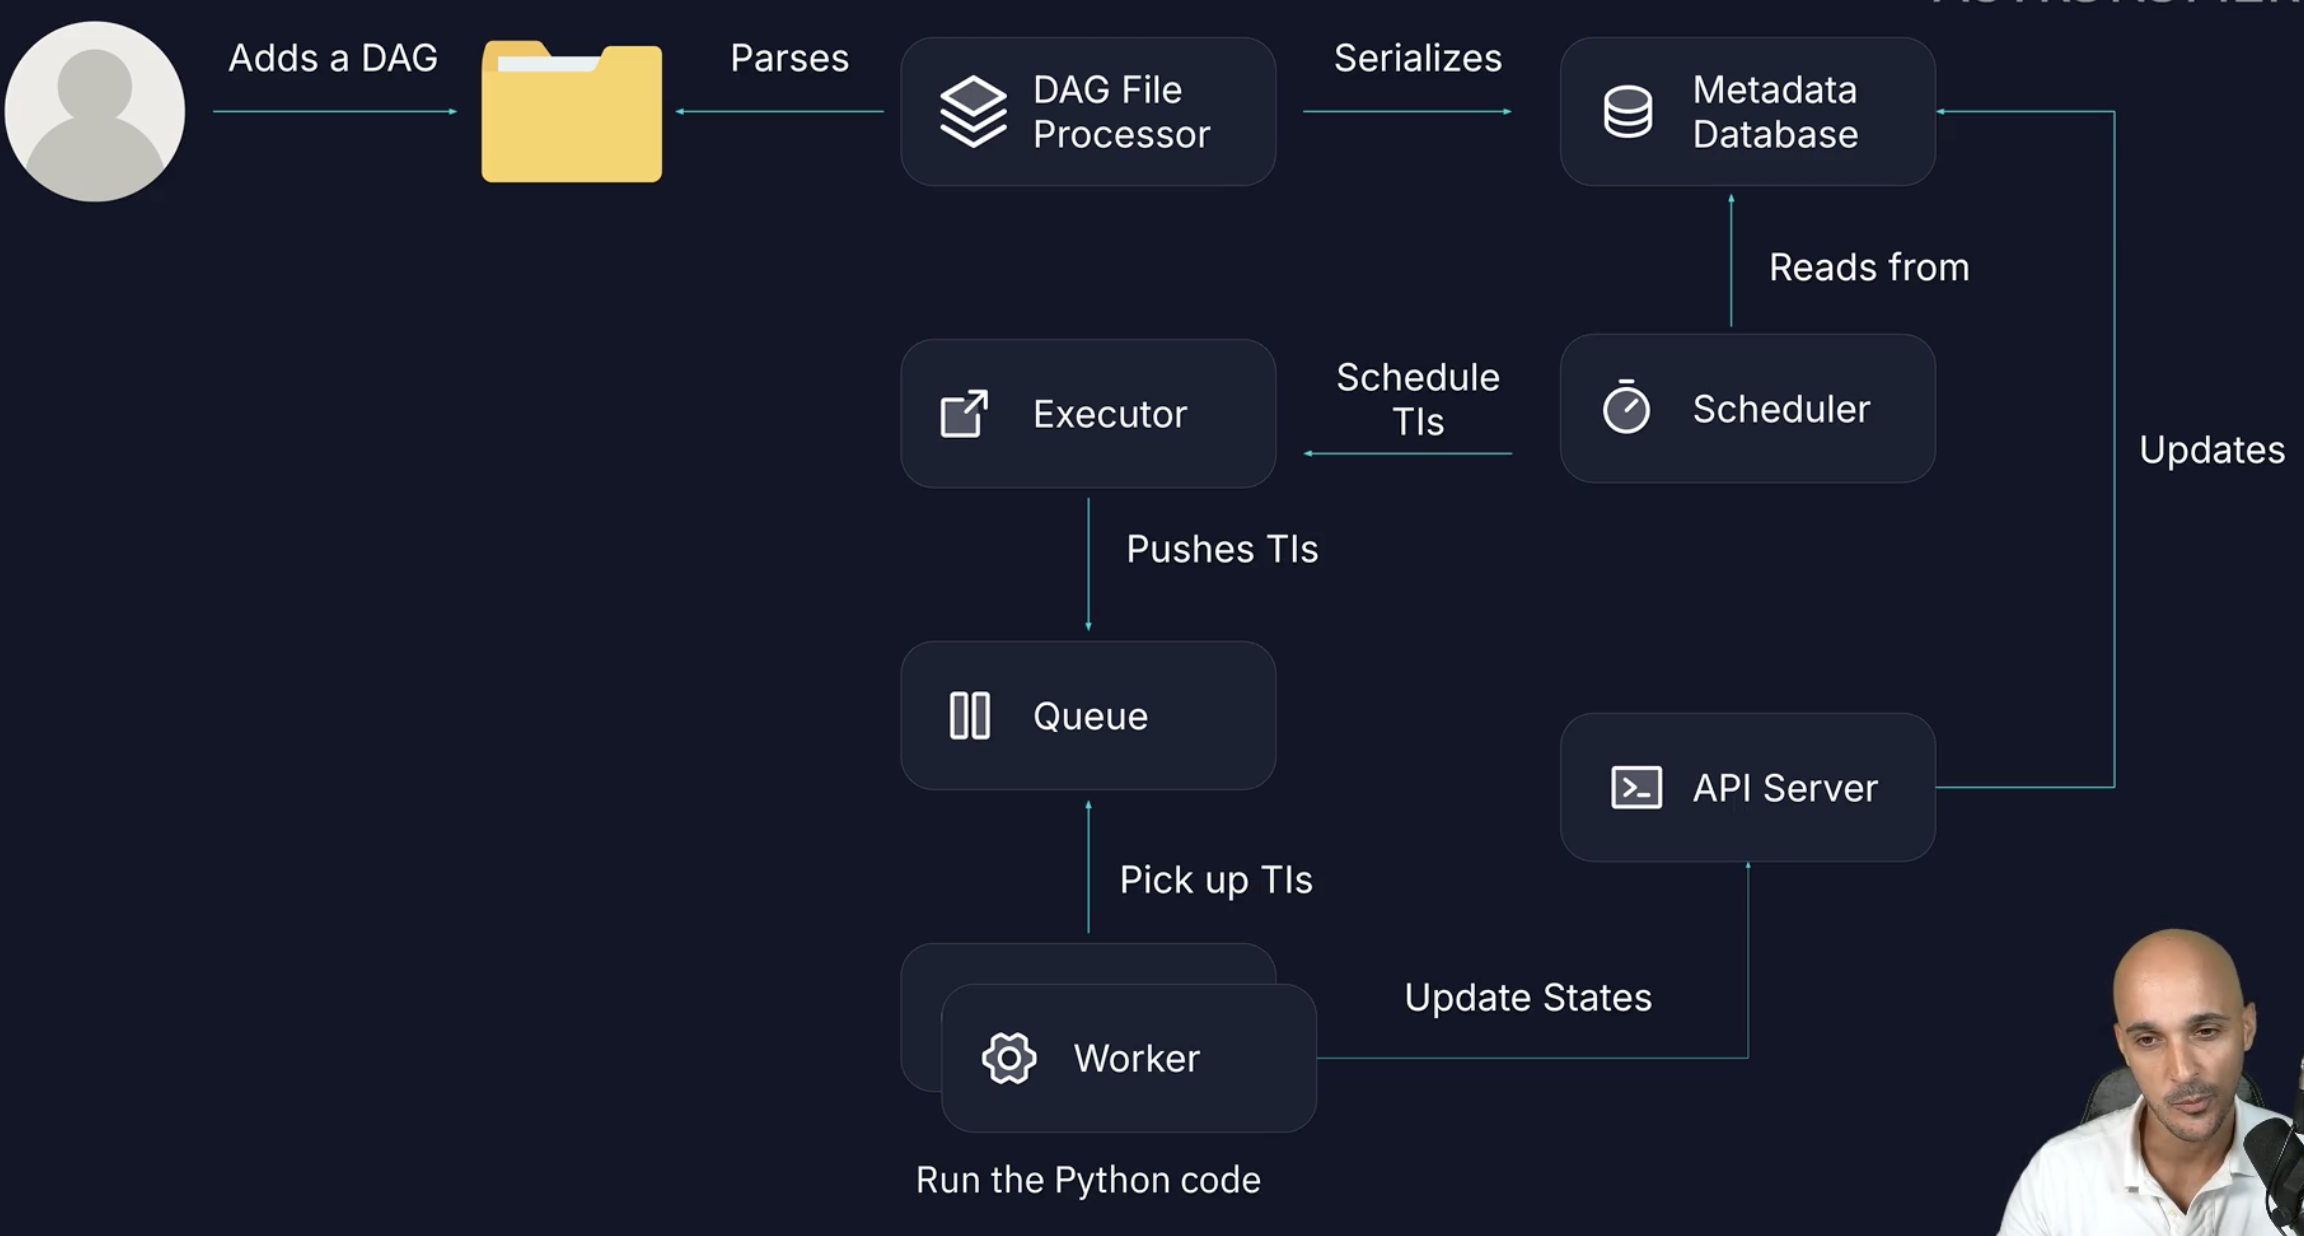

1. **DAG Addition & Parsing**     
    When a user adds a DAG file to the designated folder, the DAG File **Processor** continuously scans (**default: every 5min**) and parses these Python files to extract DAG definitions, task dependencies, and schedules.   

2. **Metadata Storage**        
    The parsed DAG information gets serialized and stored in the **Metadata Database** (typically PostgreSQL or MySQL), which serves as the central source of truth for all DAG metadata, task states, and execution history.      

3. **Scheduling**     
    The **Scheduler** reads from the metadata database to determine which **task instances (TIs)** need to run based on:

   - DAG schedules (cron expressions, intervals)
   - Task dependencies
   - Previous task completion states

4. **Task Queuing**    
    When tasks are ready to execute, the Scheduler doesn't run them directly. Instead, it creates task instances and pushes them to a **Queue** (like Redis or RabbitMQ for Celery executor, or directly for Local executor).

5. **Task Execution**     
    **Workers** (separate processes or containers) pick up task instances from the queue and execute the actual Python code defined in the DAG tasks. Workers can be:

    - Local processes (LocalExecutor)
    - Distributed Celery workers (CeleryExecutor)
    - Kubernetes pods (KubernetesExecutor)

6. **State Updates**   
    As workers execute tasks, they continuously update task states (running, success, failed) back to the metadata database through the API Server.

7. **Monitoring & Control**    
    The **API Server** provides the interface for the web UI and CLI, allowing users to monitor DAG runs, trigger manual executions, and view logs, all by querying the metadata database.
    
**Key Architectural Points**      

- Separation of concerns: Parsing, scheduling, and execution are handled by different components
- Scalability: Multiple workers can process tasks in parallel
- Reliability: The queue provides buffering and retry mechanisms
- Executor component orchestrates the relationship between scheduler and workers

This architecture allows Airflow to handle complex workflows at scale with fault tolerance and distributed execution.

## DAG Setup
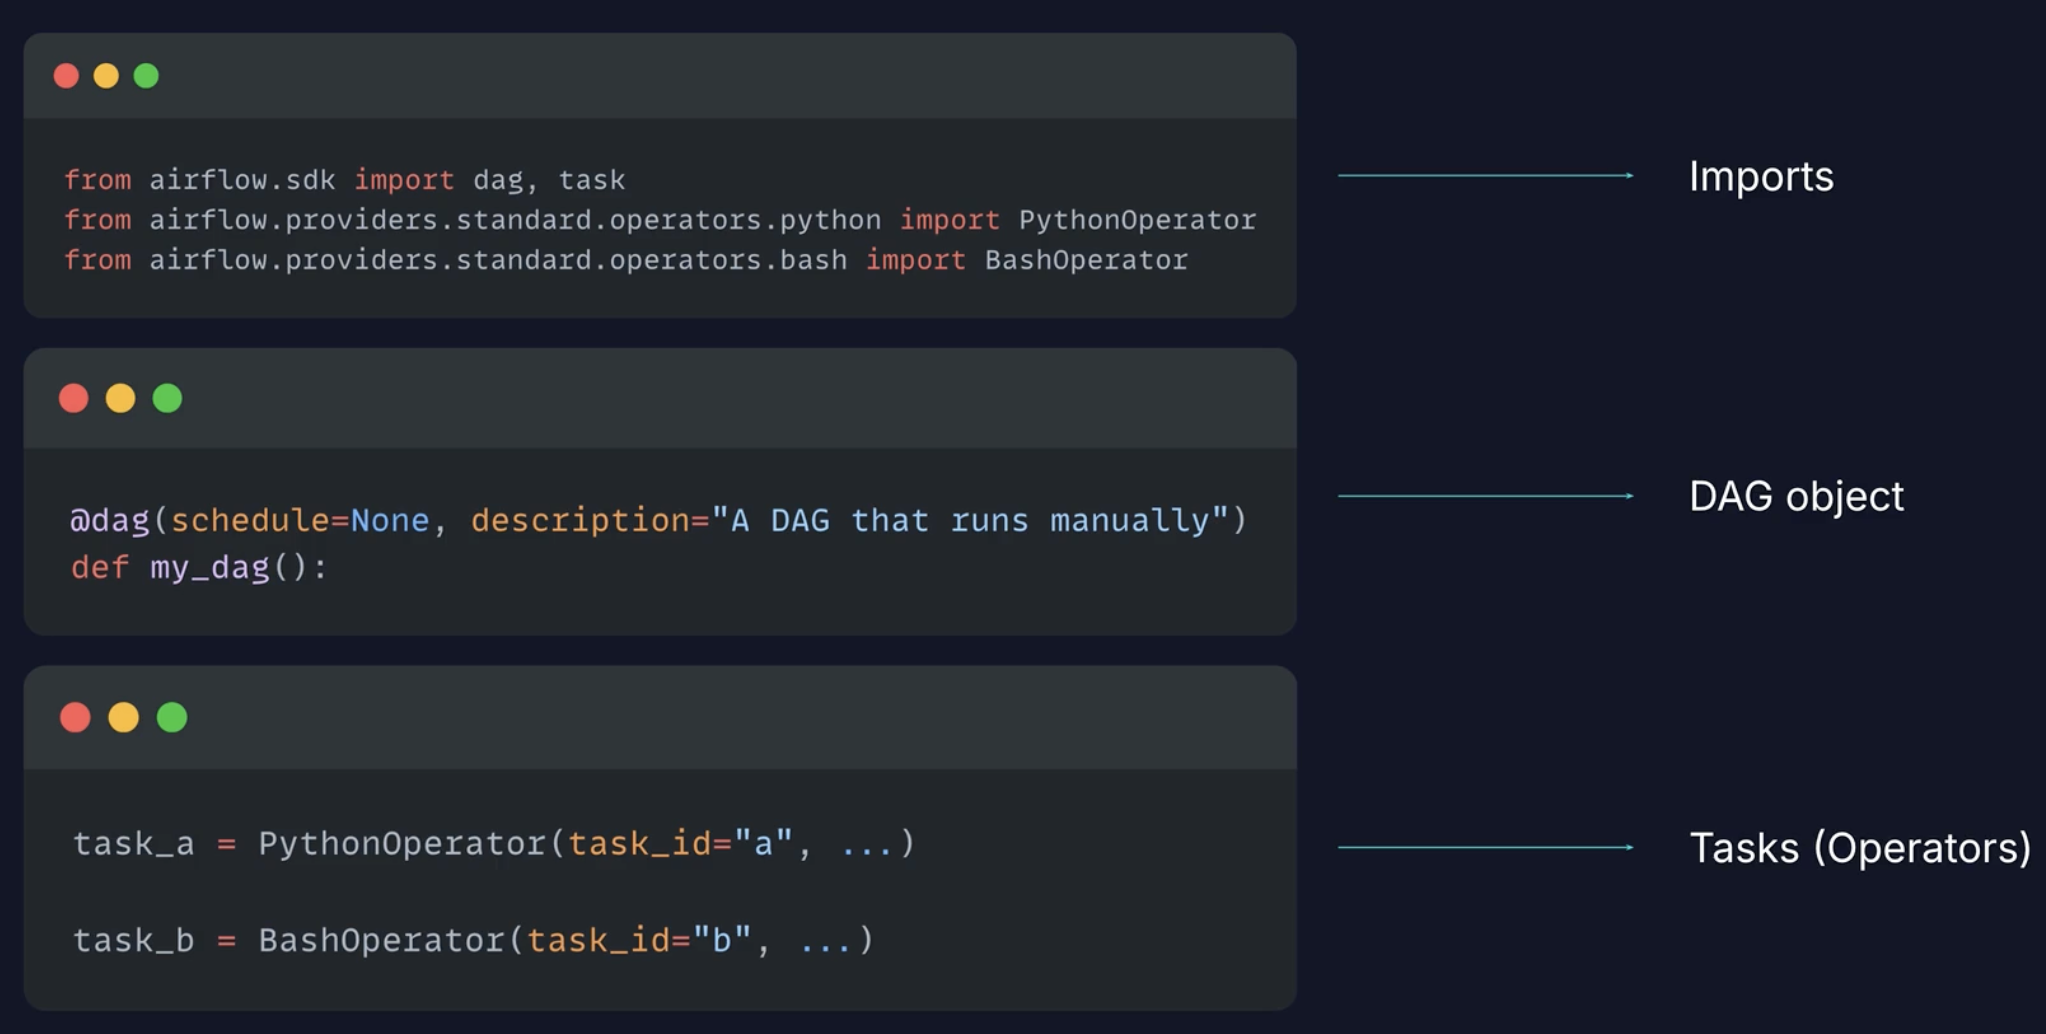  

A DAG has four core parts:
- The import statements, where the specific operators or classes that are needed for the DAG are defined.
- The DAG definition, where the DAG object is called and where specific properties, such as its name or how often you want to run it, are defined.
- The DAG body, where tasks are defined with the specific operators they will run.


## Task dependencies
The dependencies, where the order of execution of tasks is defined using the right bitshift operator (>>) and the left bitshift operator (<<).

A DAG’s task can be either upstream or downstream to another task.
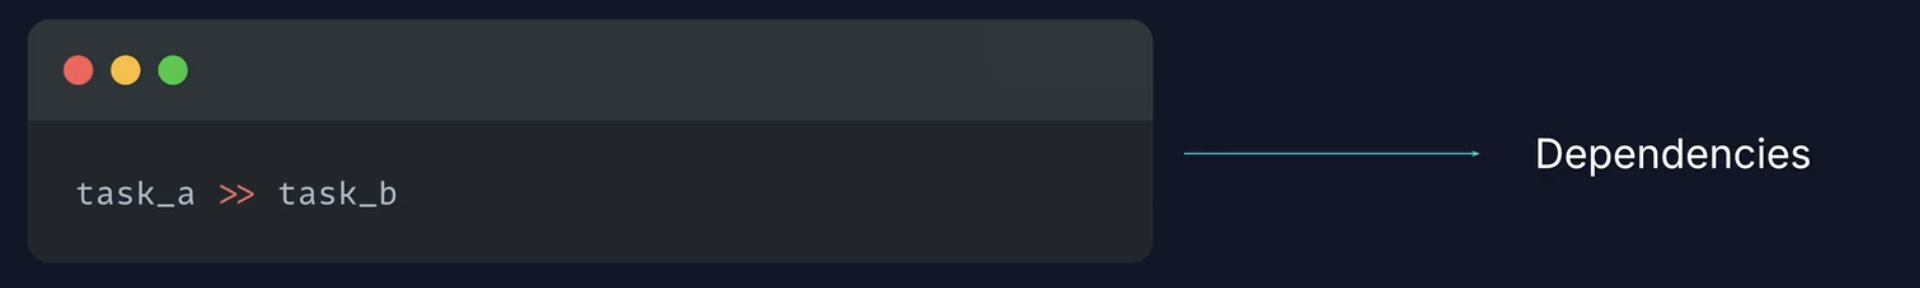  

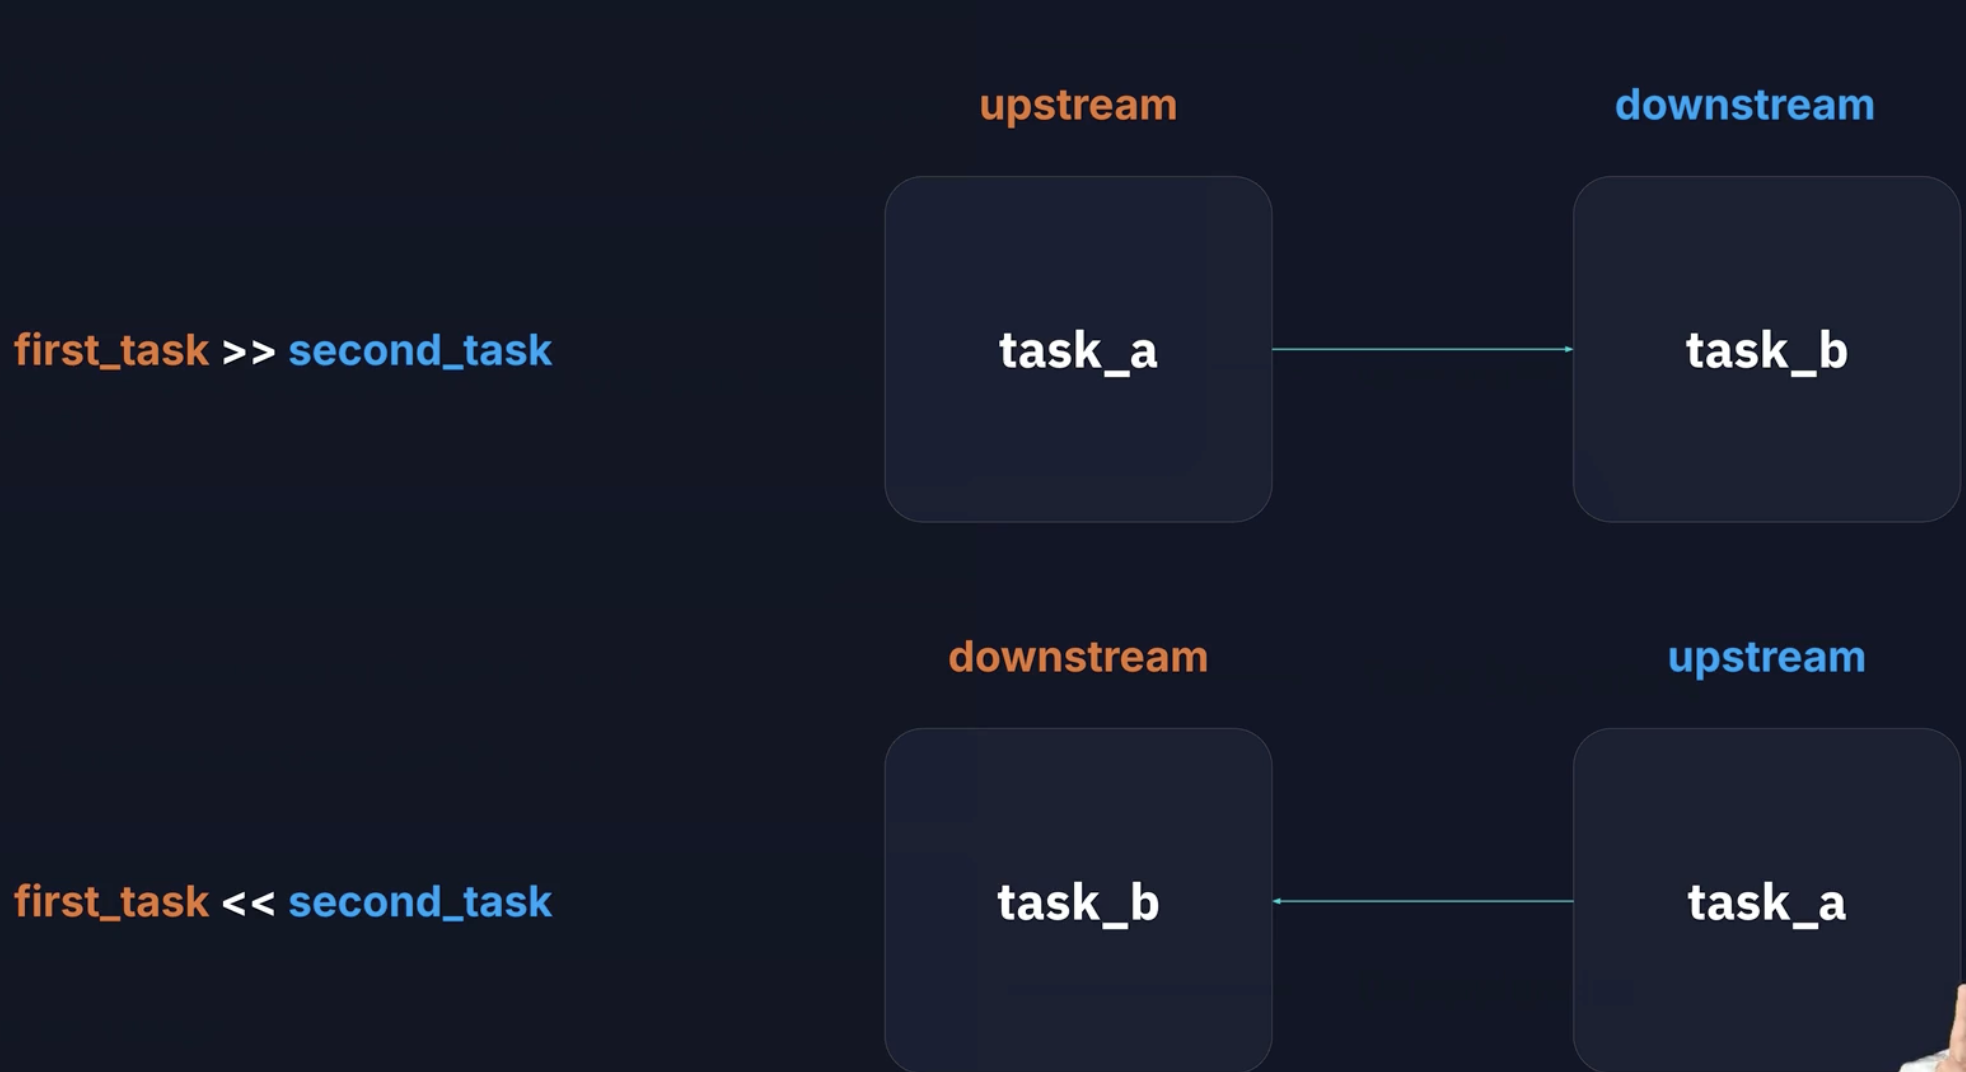

# Install
## Atro CLI
easiest way

```bash
# Download the latest release for macOS ARM (M1/M2/M3)
curl -sSL https://install.astronomer.io | sudo bash -s
# check
which astro
# /usr/local/bin/astro
astro version
# Astro CLI Version: 1.38.1
```

# Set Up a Astro Project
```bash
mkdir local_airflow
cd local_airflow
astro dev init
```

## Directory Structure
📁 dags/

- Purpose: Contains your **DAG (Directed Acyclic Graph)** Python files
- Usage: This is where you write your **Airflow workflow definitions**. Each Python file here defines tasks, dependencies, and scheduling logic
- Example: my_first_dag.py, etl_pipeline.py

📁 include/

- Purpose: Stores **helper modules, utilities, and supporting code**
- Usage: Put **reusable Python modules, SQL files, configuration files, or any code that your DAGs import**
- Example: Custom operators, utility functions, data transformation scripts
- Note: *This directory is added to the Python path automatically*

📁 plugins/

- Purpose: Houses custom Airflow plugins
- Usage: Store **custom operators, sensors, hooks, macros, or executors that extend Airflow's functionality**
- Example: Custom database operators, specialized sensors

📁 tests/

- Purpose: Contains **unit and integration tests** for your DAGs
- Usage: Write pytest tests to validate DAG integrity, task logic, and data transformations
- Example: test_dag_validation.py, test_data_quality.py

📁 .astro/

- Purpose: Astro CLI configuration and metadata
- Usage: Internal configuration for the Astro project (you **typically don't modify this manually**)

## Key Files
📄 Dockerfile

- Purpose: Defines the **Docker image for your Airflow environment**
- Usage: Customize the Airflow image by:
  - Installing additional Python packages
  - Adding system dependencies (apt packages)
  - Setting environment variables
  - Installing custom binaries


📄 requirements.txt

- Purpose: Lists Python dependencies
- Usage: Specify pip packages needed for your DAGs
- Example:
    ```text
    pandas==2.0.0
    requests==2.31.0
    apache-airflow-providers-postgres
    ```

📄 packages.txt

- Purpose: Lists OS-level (apt) packages
- Usage: Specify system dependencies needed for your project
- Example:
    ```text
    txtbuild-essential
    libpq-dev
    vim
    ```

📄 airflow_settings.yaml

- Purpose: Configures **Airflow connections, variables, and pools**
- Usage: Define **connections to databases, APIs, and external services** in a declarative way
- Example:
    ```yaml
    airflow:
    connections:
        - conn_id: my_postgres_conn
        conn_type: postgres
        host: localhost
        port: 5432
    ```

📄 .dockerignore

- Purpose: Specifies files to exclude from Docker build context
- Usage: Improves build performance by excluding unnecessary files

📄 .gitignore

- Purpose: Specifies files Git should ignore
- Usage: Prevents committing logs, cache files, and sensitive data

📄 .env

- Purpose: Environment variables for local development
- Usage: Store local configuration (not committed to Git)

📄 README.md

- Purpose: Project documentation
- Usage: Document your project setup, DAG descriptions, and development guidelines

## Typical Workflow

- Write DAGs in dags/ directory
- Add utilities to include/ (SQL queries, helper functions)
- Install dependencies via requirements.txt or packages.txt
- Configure connections in airflow_settings.yaml
- Write tests in tests/ directory
- Run locally: 
  ```bash
  astro dev start
  ```
- Access Airflow UI: http://localhost:8080 (default credentials: admin/admin)

- to stop, restart, kill:
  ```bash
  astro dev strop
  astro dev restart
  astro dev kill
  ```


To get Airflow **to work with VSCode** and provide benefits like **correct syntax highlighting and autocompletion**, the VSCode instance must be run **inside of the docker container** using the Dev Containers extension.